In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree, export_text
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                             f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.manifold import TSNE
import umap, trimap, pacmap
from imblearn.datasets import fetch_datasets

np.random.seed(42)
sns.set_style('whitegrid')

### Load dataset

In [2]:
ozone = fetch_datasets(filter_data=('ozone_level',))['ozone_level']
X = ozone.data
y = ozone.target

print(f"Dataset: ozone_level")
print(f"Shape: {X.shape}")
print(f"Class distribution: {np.bincount(y.astype(int) + 1)}  → minority={sum(y==-1)}, majority={sum(y==1)}")

Dataset: ozone_level
Shape: (2536, 72)
Class distribution: [2463    0   73]  → minority=2463, majority=73


### Train/Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class counts: {np.bincount(y_train.astype(int) + 1)}")
print(f"Test class counts:  {np.bincount(y_test.astype(int) + 1)}")

# Scale for SVM and KNN (RF doesn't need it, but for consistency we scale all)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

Train: (1775, 72), Test: (761, 72)
Train class counts: [1724    0   51]
Test class counts:  [739   0  22]


### PART A
##### Grid search over kernels

In [4]:
# Grid search over kernels and hyperparameters
param_grid = [
    # Linear kernel — only C matters
    {'kernel': ['linear'], 'C': [0.01, 0.1, 1, 10, 100]},

    # RBF kernel — C and gamma
    {'kernel': ['rbf'], 'C': [0.1, 1, 10, 100],
     'gamma': ['scale', 'auto', 0.001, 0.01, 0.1]},

    # Polynomial kernel — C, degree, gamma, coef0
    {'kernel': ['poly'], 'C': [0.1, 1, 10],
     'degree': [2, 3, 4], 'gamma': ['scale', 'auto'],
     'coef0': [0, 1]},

    # Sigmoid (tanh) kernel — C, gamma, coef0
    {'kernel': ['sigmoid'], 'C': [0.1, 1, 10],
     'gamma': ['scale', 'auto'], 'coef0': [0, 1]},
]

svm_base = SVC(class_weight='balanced', random_state=42)

# Use F1 on the minority class as the scoring metric (imbalanced data!)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

start = time.time()
svm_grid = GridSearchCV(
    svm_base, param_grid,
    scoring='f1',         # F1 for minority class (positive label = -1)
    cv=cv, n_jobs=-1, verbose=1
)
svm_grid.fit(X_train_s, y_train)
svm_time = time.time() - start

print(f"\nGrid search time: {svm_time:.1f}s")
print(f"Best params: {svm_grid.best_params_}")
print(f"Best CV F1:  {svm_grid.best_score_:.4f}")

Fitting 3 folds for each of 73 candidates, totalling 219 fits

Grid search time: 9.5s
Best params: {'C': 1, 'coef0': 1, 'degree': 4, 'gamma': 'scale', 'kernel': 'poly'}
Best CV F1:  0.4124


### Evaluate best SVM

In [5]:
best_svm = svm_grid.best_estimator_

# Predictions
y_train_pred = best_svm.predict(X_train_s)
y_test_pred  = best_svm.predict(X_test_s)

def evaluate(y_true, y_pred, label):
    acc  = accuracy_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred, pos_label=-1)     # minority = positive
    prec = precision_score(y_true, y_pred, pos_label=-1)
    f1   = f1_score(y_true, y_pred, pos_label=-1)
    print(f"\n--- {label} ---")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Recall   : {rec:.4f}   (minority = -1)")
    print(f"  Precision: {prec:.4f}   (minority = -1)")
    print(f"  F1       : {f1:.4f}   (minority = -1)")
    return acc, rec, prec, f1

evaluate(y_train, y_train_pred, 'SVM — Train')
evaluate(y_test,  y_test_pred,  'SVM — Test')

print(f"\nNumber of support vectors: {len(best_svm.support_)}")
print(f"  Per class: {best_svm.n_support_}")
print(f"  Fraction of training set: {len(best_svm.support_) / len(X_train_s):.3f}")


--- SVM — Train ---
  Accuracy : 0.9904
  Recall   : 0.9901   (minority = -1)
  Precision: 1.0000   (minority = -1)
  F1       : 0.9950   (minority = -1)

--- SVM — Test ---
  Accuracy : 0.9514
  Recall   : 0.9756   (minority = -1)
  Precision: 0.9743   (minority = -1)
  F1       : 0.9750   (minority = -1)

Number of support vectors: 222
  Per class: [183  39]
  Fraction of training set: 0.125


### Confusion Matrices

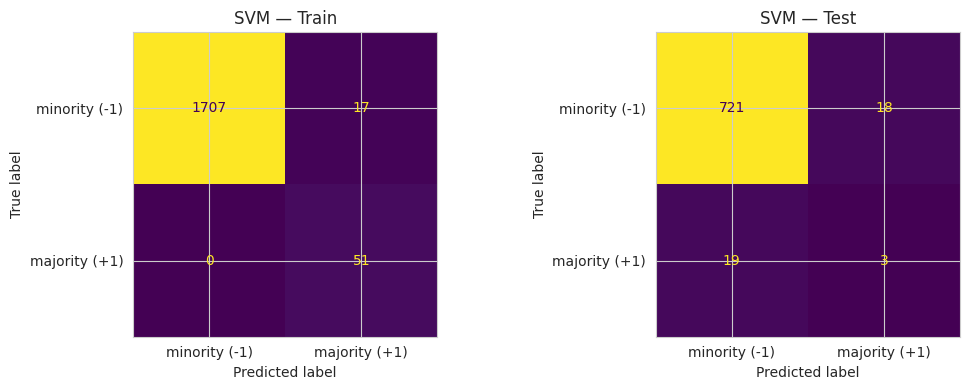

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (y_t, y_p, title) in zip(axes, [
    (y_train, y_train_pred, 'SVM — Train'),
    (y_test,  y_test_pred,  'SVM — Test'),
]):
    cm = confusion_matrix(y_t, y_p, labels=[-1, 1])
    ConfusionMatrixDisplay(cm, display_labels=['minority (-1)', 'majority (+1)']).plot(ax=ax, colorbar=False)
    ax.set_title(title)
plt.tight_layout()
plt.savefig('svm_confusion.png', dpi=150)
plt.show()

### Visualize SVM with t-SNE, UMAP, TriMap, PaCMAP

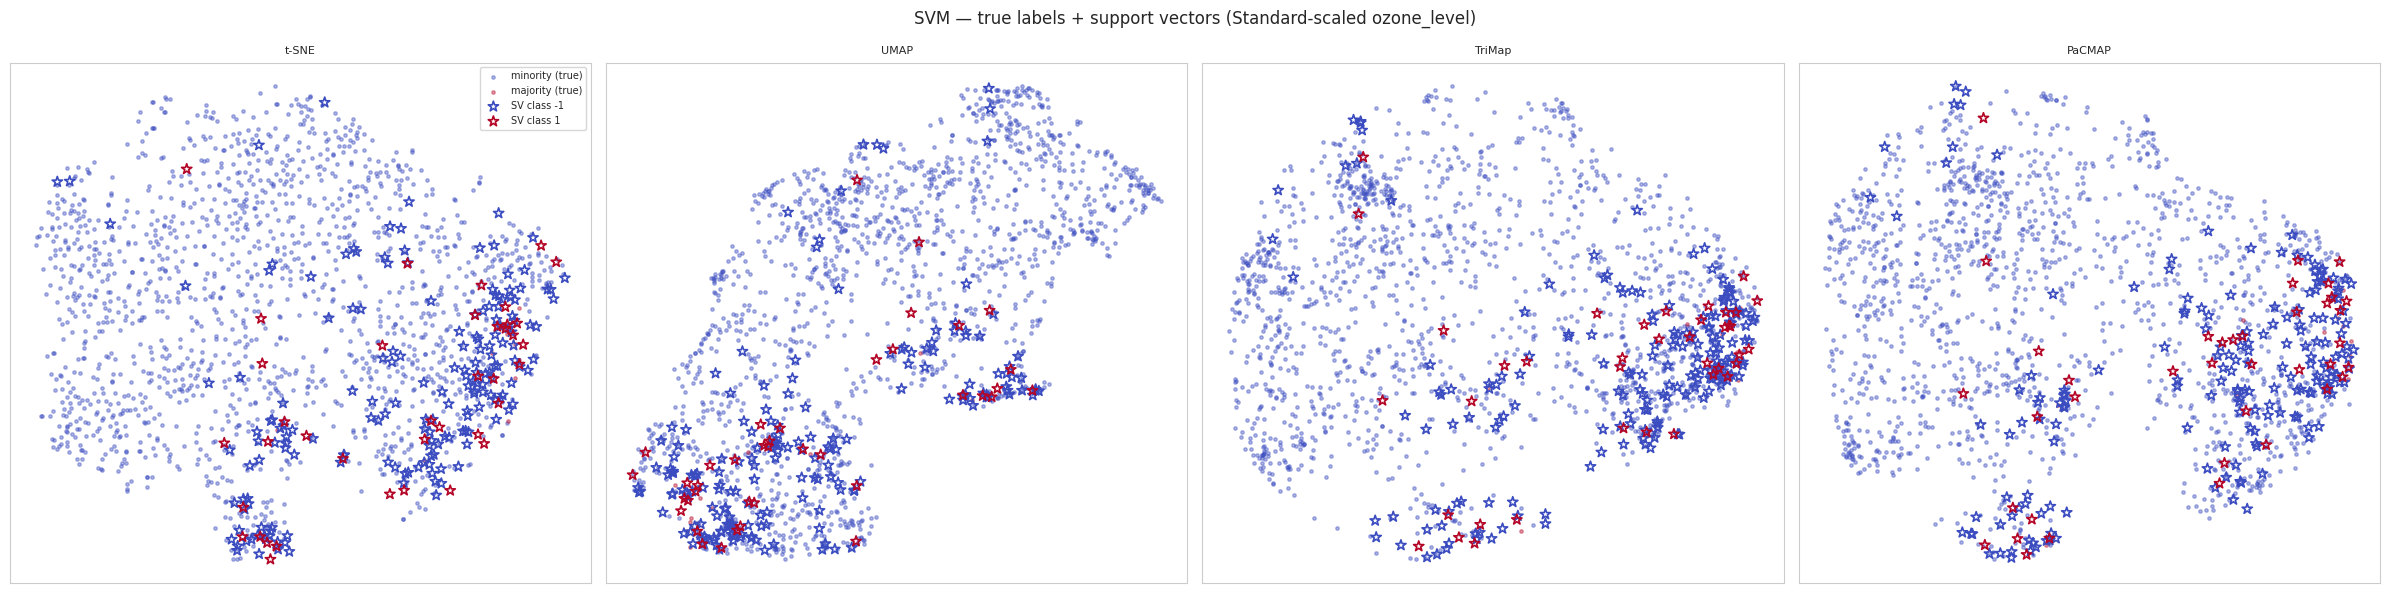

In [7]:
def visualize_svm(X_2d, y_true, y_pred, sv_mask, title, ax):
    """
    Plot 2D embedding with:
      - true class colors: minority = blue, majority = red
      - support vectors marked with stars
      - predicted class shown via marker shape
    """
    # Plot non-SV points (circles)
    for cls, color, label in [(-1, '#3b4cc0', 'minority'), (1, '#b40426', 'majority')]:
        mask = (y_true == cls) & (~sv_mask)
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=color, s=6, alpha=0.4, marker='o',
                   label=f'{label} (true)')

    # Plot support vectors (stars, outlined)
    for cls, color in [(-1, '#3b4cc0'), (1, '#b40426')]:
        mask = sv_mask & (y_true == cls)
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   facecolors='none', edgecolors=color,
                   s=60, marker='*', linewidths=1.2,
                   label=f'SV class {cls}')

    ax.set_title(title, fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])

# Compute SV mask on training data
sv_train_mask = np.zeros(len(X_train_s), dtype=bool)
sv_train_mask[best_svm.support_] = True

# Four embeddings (default params) on the STANDARD-scaled full data
# (embeddings are computed on the full X for visualization purposes)
embeddings = {}

embeddings['t-SNE'] = TSNE(n_components=2, perplexity=30, random_state=42,
                            init='pca', max_iter=1000).fit_transform(X_train_s)

embeddings['UMAP'] = umap.UMAP(n_components=2, n_neighbors=15,
                               min_dist=0.1, random_state=42).fit_transform(X_train_s)

embeddings['TriMap'] = trimap.TRIMAP(n_inliers=10, n_outliers=5,
                                     n_random=5, n_iters=400).fit_transform(X_train_s)

embeddings['PaCMAP'] = pacmap.PaCMAP(n_components=2, n_neighbors=10,
                                     MN_ratio=0.5, FP_ratio=2.0,
                                     random_state=42).fit_transform(X_train_s, init='pca')

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
for ax, (name, X_2d) in zip(axes, embeddings.items()):
    visualize_svm(X_2d, y_train, y_train_pred, sv_train_mask, name, ax)
axes[0].legend(loc='upper right', fontsize=7)
plt.suptitle('SVM — true labels + support vectors (Standard-scaled ozone_level)')
plt.tight_layout()
plt.savefig('svm_embeddings.png', dpi=150)
plt.show()

### Predicted vs True Labels

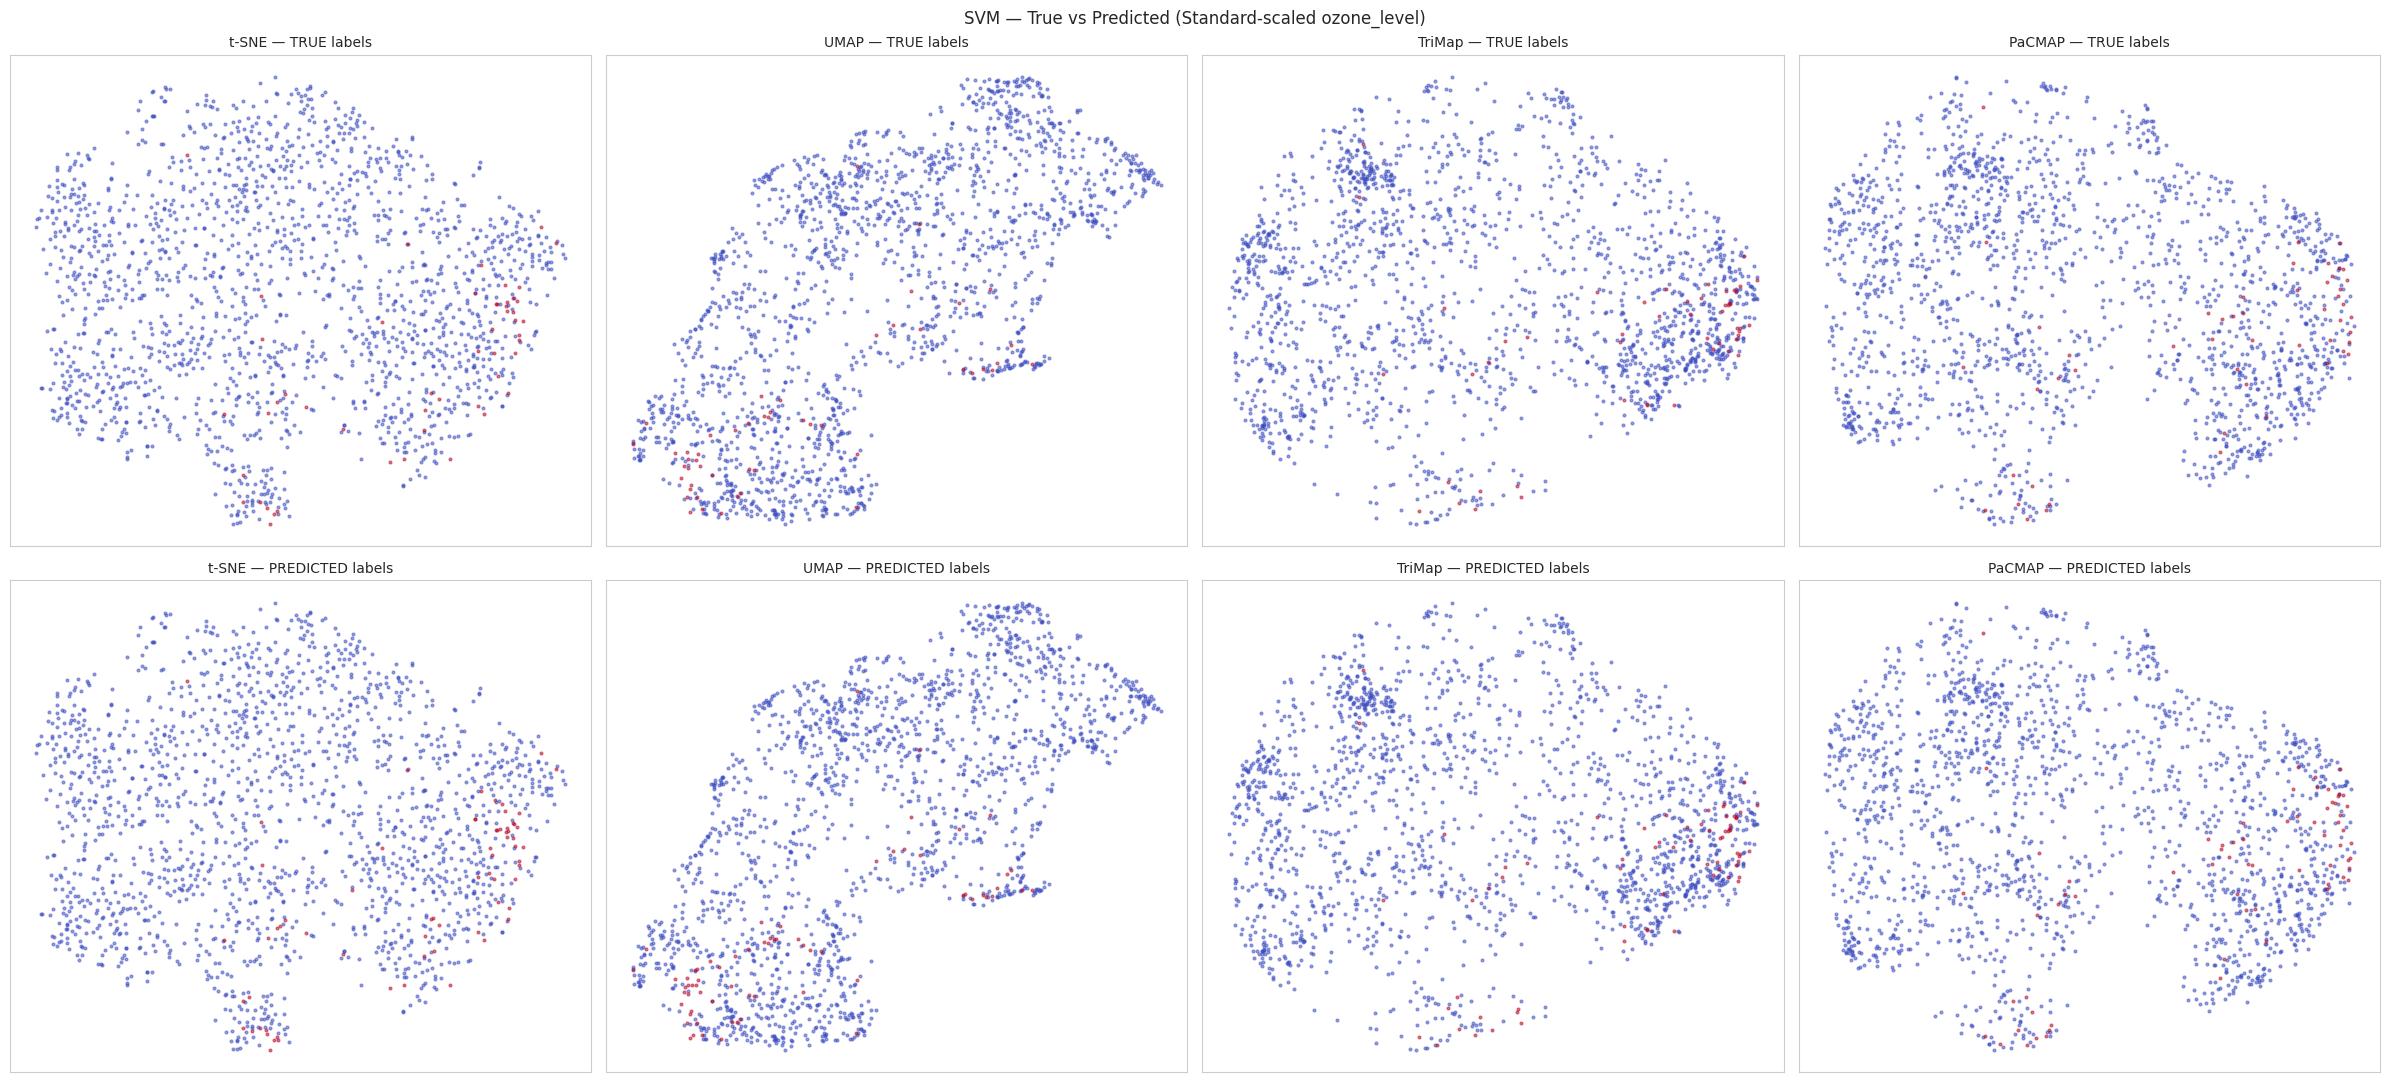

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(24, 11))

for col, (name, X_2d) in enumerate(embeddings.items()):
    # Top row — TRUE labels
    for cls, color in [(-1, '#3b4cc0'), (1, '#b40426')]:
        m = (y_train == cls)
        axes[0, col].scatter(X_2d[m, 0], X_2d[m, 1], c=color, s=4, alpha=0.5)
    axes[0, col].set_title(f'{name} — TRUE labels', fontsize=10)

    # Bottom row — PREDICTED labels
    for cls, color in [(-1, '#3b4cc0'), (1, '#b40426')]:
        m = (y_train_pred == cls)
        axes[1, col].scatter(X_2d[m, 0], X_2d[m, 1], c=color, s=4, alpha=0.5)
    axes[1, col].set_title(f'{name} — PREDICTED labels', fontsize=10)

    for r in range(2):
        axes[r, col].set_xticks([]); axes[r, col].set_yticks([])

plt.suptitle('SVM — True vs Predicted (Standard-scaled ozone_level)')
plt.tight_layout()
plt.savefig('svm_true_vs_pred.png', dpi=150)
plt.show()

### PART B - KNN Classifier
##### Grid Search

In [9]:
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21, 31],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'chebyshev', 'minkowski'],
}

knn_base = KNeighborsClassifier()

knn_grid = GridSearchCV(
    knn_base, knn_param_grid,
    scoring='f1', cv=cv, n_jobs=-1, verbose=1
)

start = time.time()
knn_grid.fit(X_train_s, y_train)
knn_time = time.time() - start

print(f"\nKNN grid search time: {knn_time:.1f}s")
print(f"Best params: {knn_grid.best_params_}")
print(f"Best CV F1:  {knn_grid.best_score_:.4f}")

Fitting 3 folds for each of 64 candidates, totalling 192 fits

KNN grid search time: 1.2s
Best params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
Best CV F1:  0.3149


### Evaluate Best KNN

In [10]:
best_knn = knn_grid.best_estimator_
y_train_pred_knn = best_knn.predict(X_train_s)
y_test_pred_knn  = best_knn.predict(X_test_s)

evaluate(y_train, y_train_pred_knn, 'KNN — Train')
evaluate(y_test,  y_test_pred_knn,  'KNN — Test')


--- KNN — Train ---
  Accuracy : 0.9763
  Recall   : 0.9948   (minority = -1)
  Precision: 0.9811   (minority = -1)
  F1       : 0.9879   (minority = -1)

--- KNN — Test ---
  Accuracy : 0.9711
  Recall   : 0.9973   (minority = -1)
  Precision: 0.9736   (minority = -1)
  F1       : 0.9853   (minority = -1)


(0.9710906701708278,
 0.9972936400541272,
 0.9735799207397622,
 0.9852941176470589)

### Visualize KNN

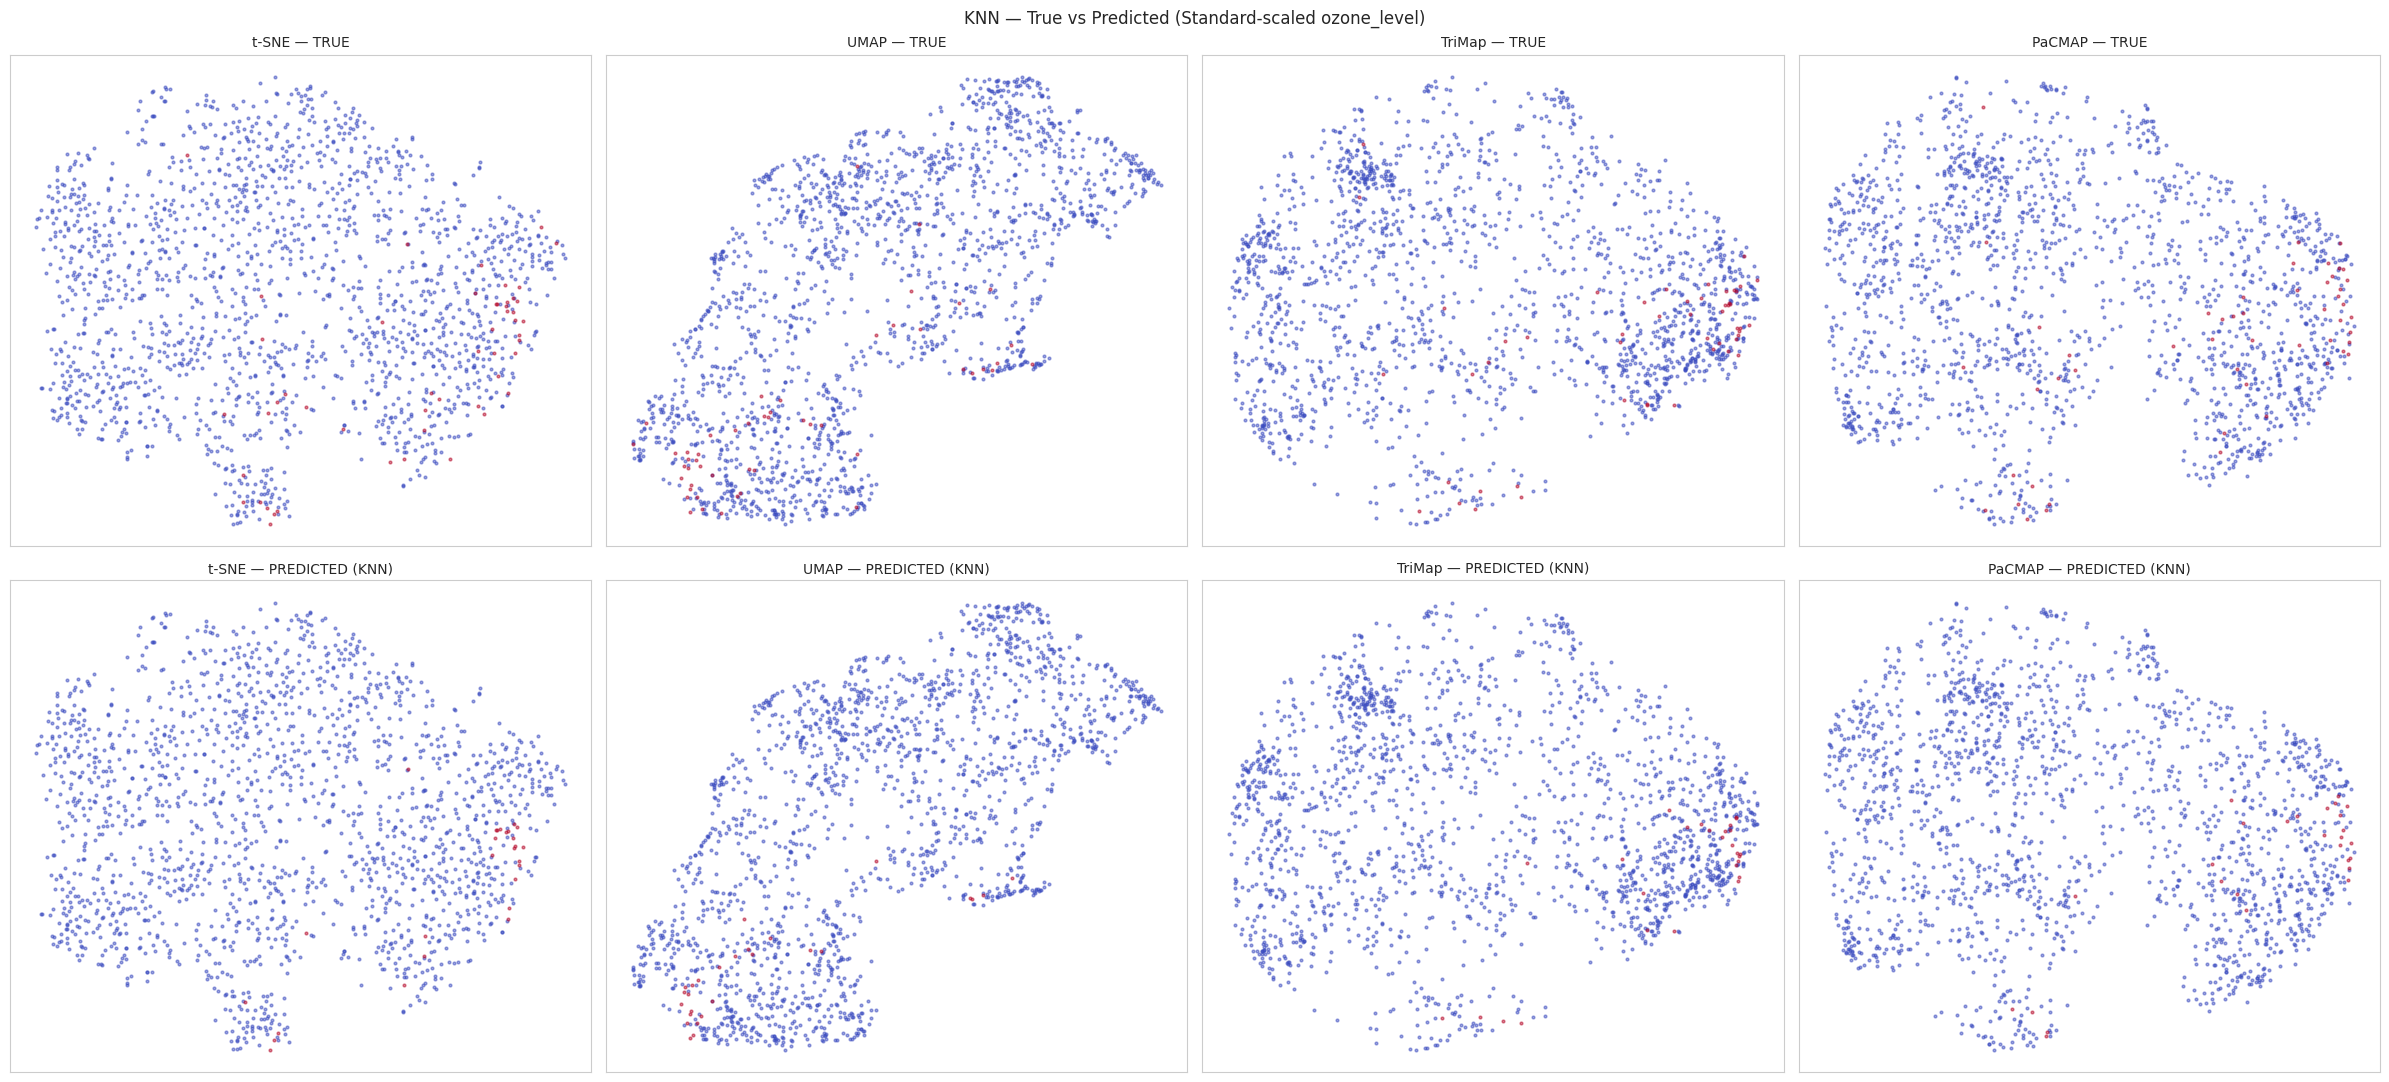

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(24, 11))

for col, (name, X_2d) in enumerate(embeddings.items()):
    # True
    for cls, color in [(-1, '#3b4cc0'), (1, '#b40426')]:
        m = (y_train == cls)
        axes[0, col].scatter(X_2d[m, 0], X_2d[m, 1], c=color, s=4, alpha=0.5)
    axes[0, col].set_title(f'{name} — TRUE', fontsize=10)

    # Predicted
    for cls, color in [(-1, '#3b4cc0'), (1, '#b40426')]:
        m = (y_train_pred_knn == cls)
        axes[1, col].scatter(X_2d[m, 0], X_2d[m, 1], c=color, s=4, alpha=0.5)
    axes[1, col].set_title(f'{name} — PREDICTED (KNN)', fontsize=10)

    for r in range(2):
        axes[r, col].set_xticks([]); axes[r, col].set_yticks([])

plt.suptitle('KNN — True vs Predicted (Standard-scaled ozone_level)')
plt.tight_layout()
plt.savefig('knn_true_vs_pred.png', dpi=150)
plt.show()

### PART C - Random Forest Classifier
##### Grid Search

In [12]:
rf_param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced', 'balanced_subsample'],
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

rf_grid = GridSearchCV(
    rf_base, rf_param_grid,
    scoring='f1', cv=cv, n_jobs=-1, verbose=1
)

start = time.time()
rf_grid.fit(X_train_s, y_train)
rf_time = time.time() - start

print(f"\nRF grid search time: {rf_time:.1f}s")
print(f"Best params: {rf_grid.best_params_}")
print(f"Best CV F1:  {rf_grid.best_score_:.4f}")

Fitting 3 folds for each of 576 candidates, totalling 1728 fits

RF grid search time: 162.2s
Best params: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}
Best CV F1:  0.4341


### Evaluate Best RF

In [13]:
best_rf = rf_grid.best_estimator_
y_train_pred_rf = best_rf.predict(X_train_s)
y_test_pred_rf  = best_rf.predict(X_test_s)

evaluate(y_train, y_train_pred_rf, 'RF — Train')
evaluate(y_test,  y_test_pred_rf,  'RF — Test')


--- RF — Train ---
  Accuracy : 0.9673
  Recall   : 0.9669   (minority = -1)
  Precision: 0.9994   (minority = -1)
  F1       : 0.9829   (minority = -1)

--- RF — Test ---
  Accuracy : 0.9396
  Recall   : 0.9526   (minority = -1)
  Precision: 0.9846   (minority = -1)
  F1       : 0.9684   (minority = -1)


(0.9395532194480947, 0.952638700947226, 0.9846153846153847, 0.9683631361760661)

### Visualize RF Embeddings

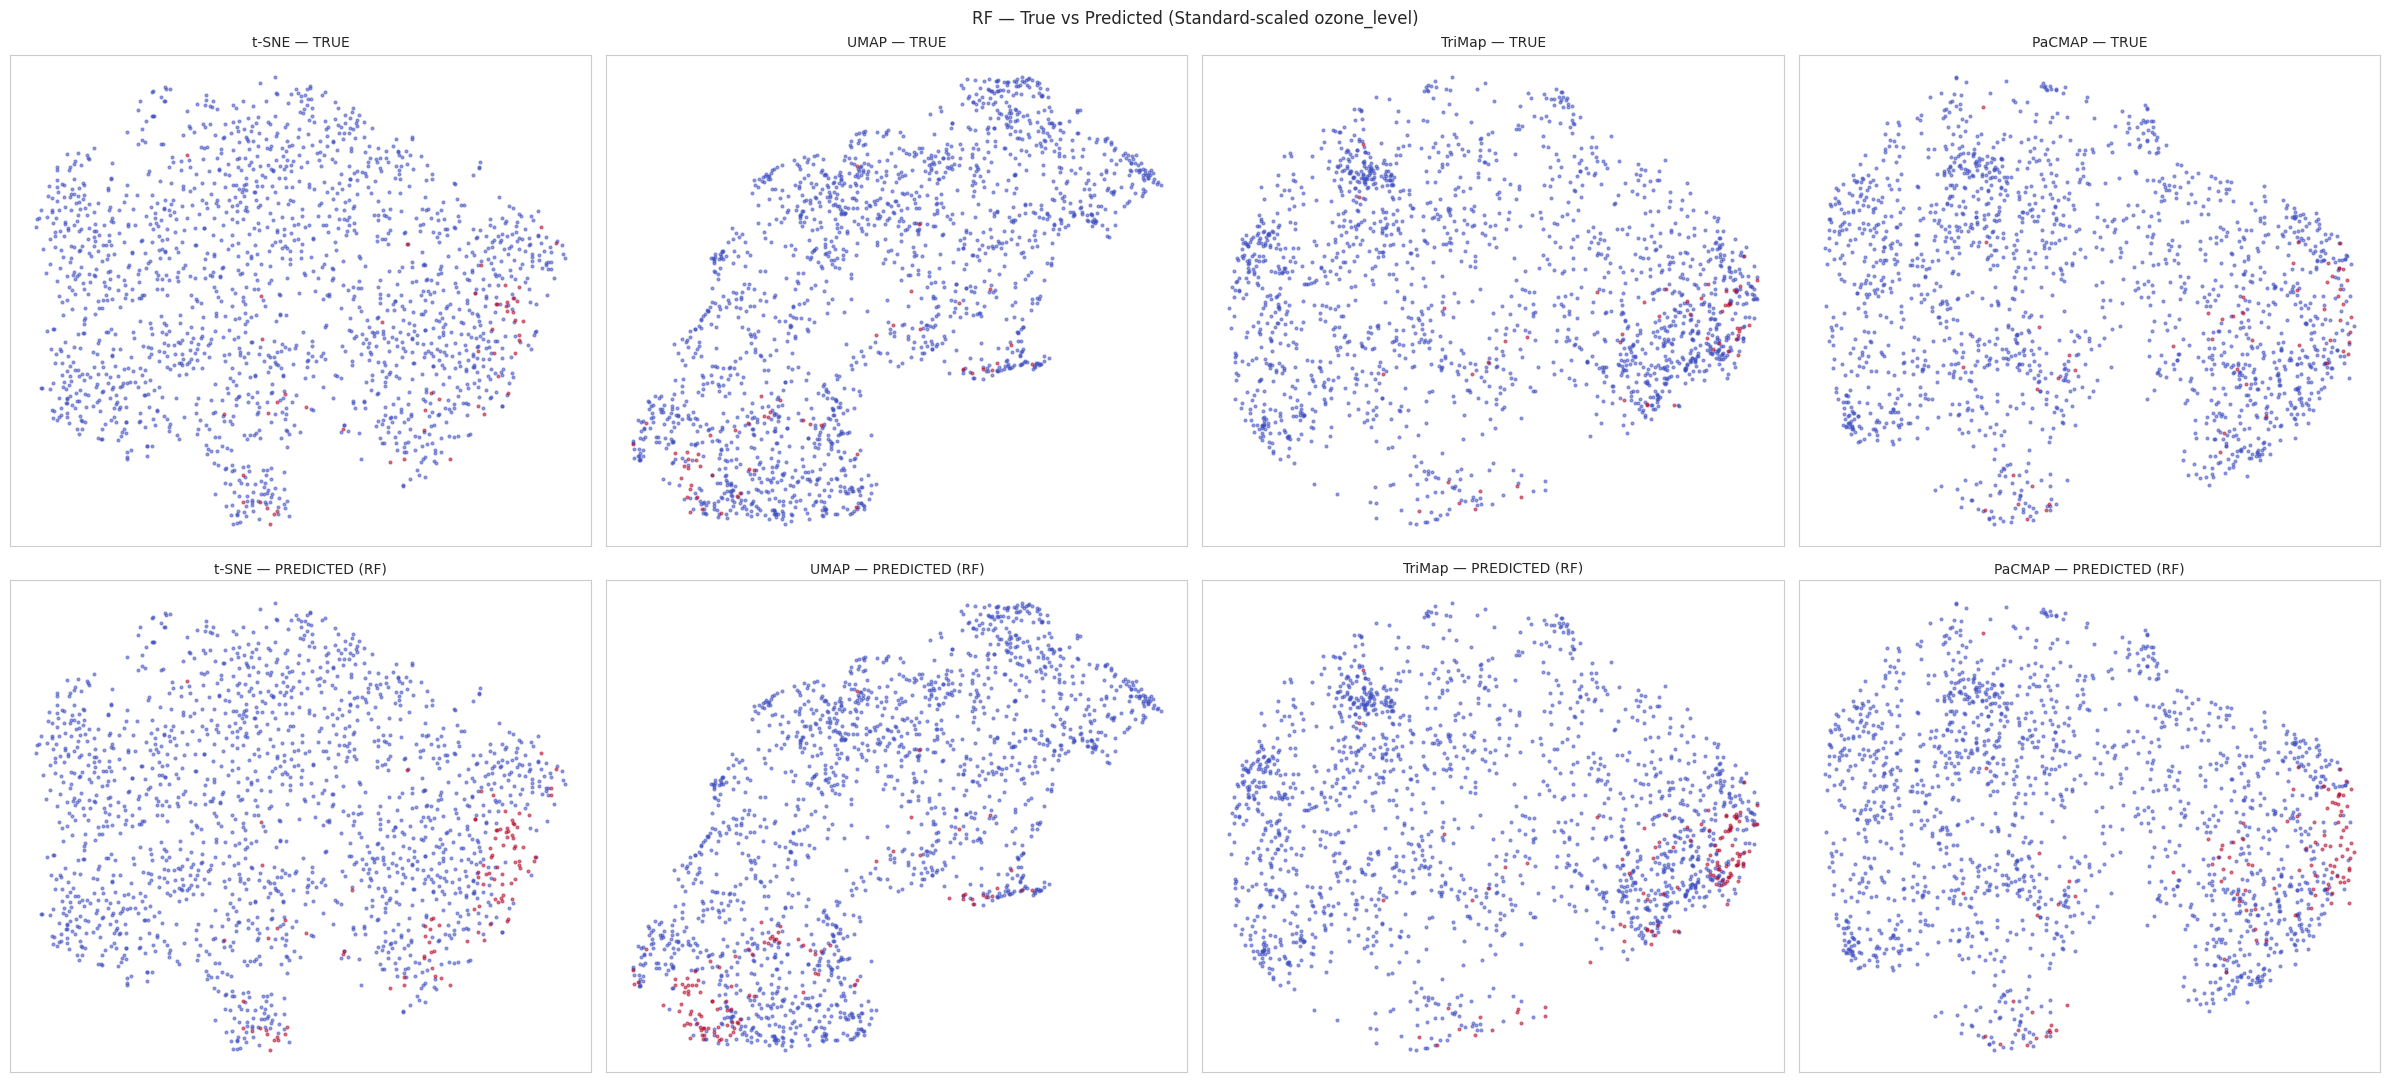

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(24, 11))

for col, (name, X_2d) in enumerate(embeddings.items()):
    for cls, color in [(-1, '#3b4cc0'), (1, '#b40426')]:
        m = (y_train == cls)
        axes[0, col].scatter(X_2d[m, 0], X_2d[m, 1], c=color, s=4, alpha=0.5)
    axes[0, col].set_title(f'{name} — TRUE', fontsize=10)

    for cls, color in [(-1, '#3b4cc0'), (1, '#b40426')]:
        m = (y_train_pred_rf == cls)
        axes[1, col].scatter(X_2d[m, 0], X_2d[m, 1], c=color, s=4, alpha=0.5)
    axes[1, col].set_title(f'{name} — PREDICTED (RF)', fontsize=10)

    for r in range(2):
        axes[r, col].set_xticks([]); axes[r, col].set_yticks([])

plt.suptitle('RF — True vs Predicted (Standard-scaled ozone_level)')
plt.tight_layout()
plt.savefig('rf_true_vs_pred.png', dpi=150)
plt.show()

### Visualize 2 Trees from the Forest

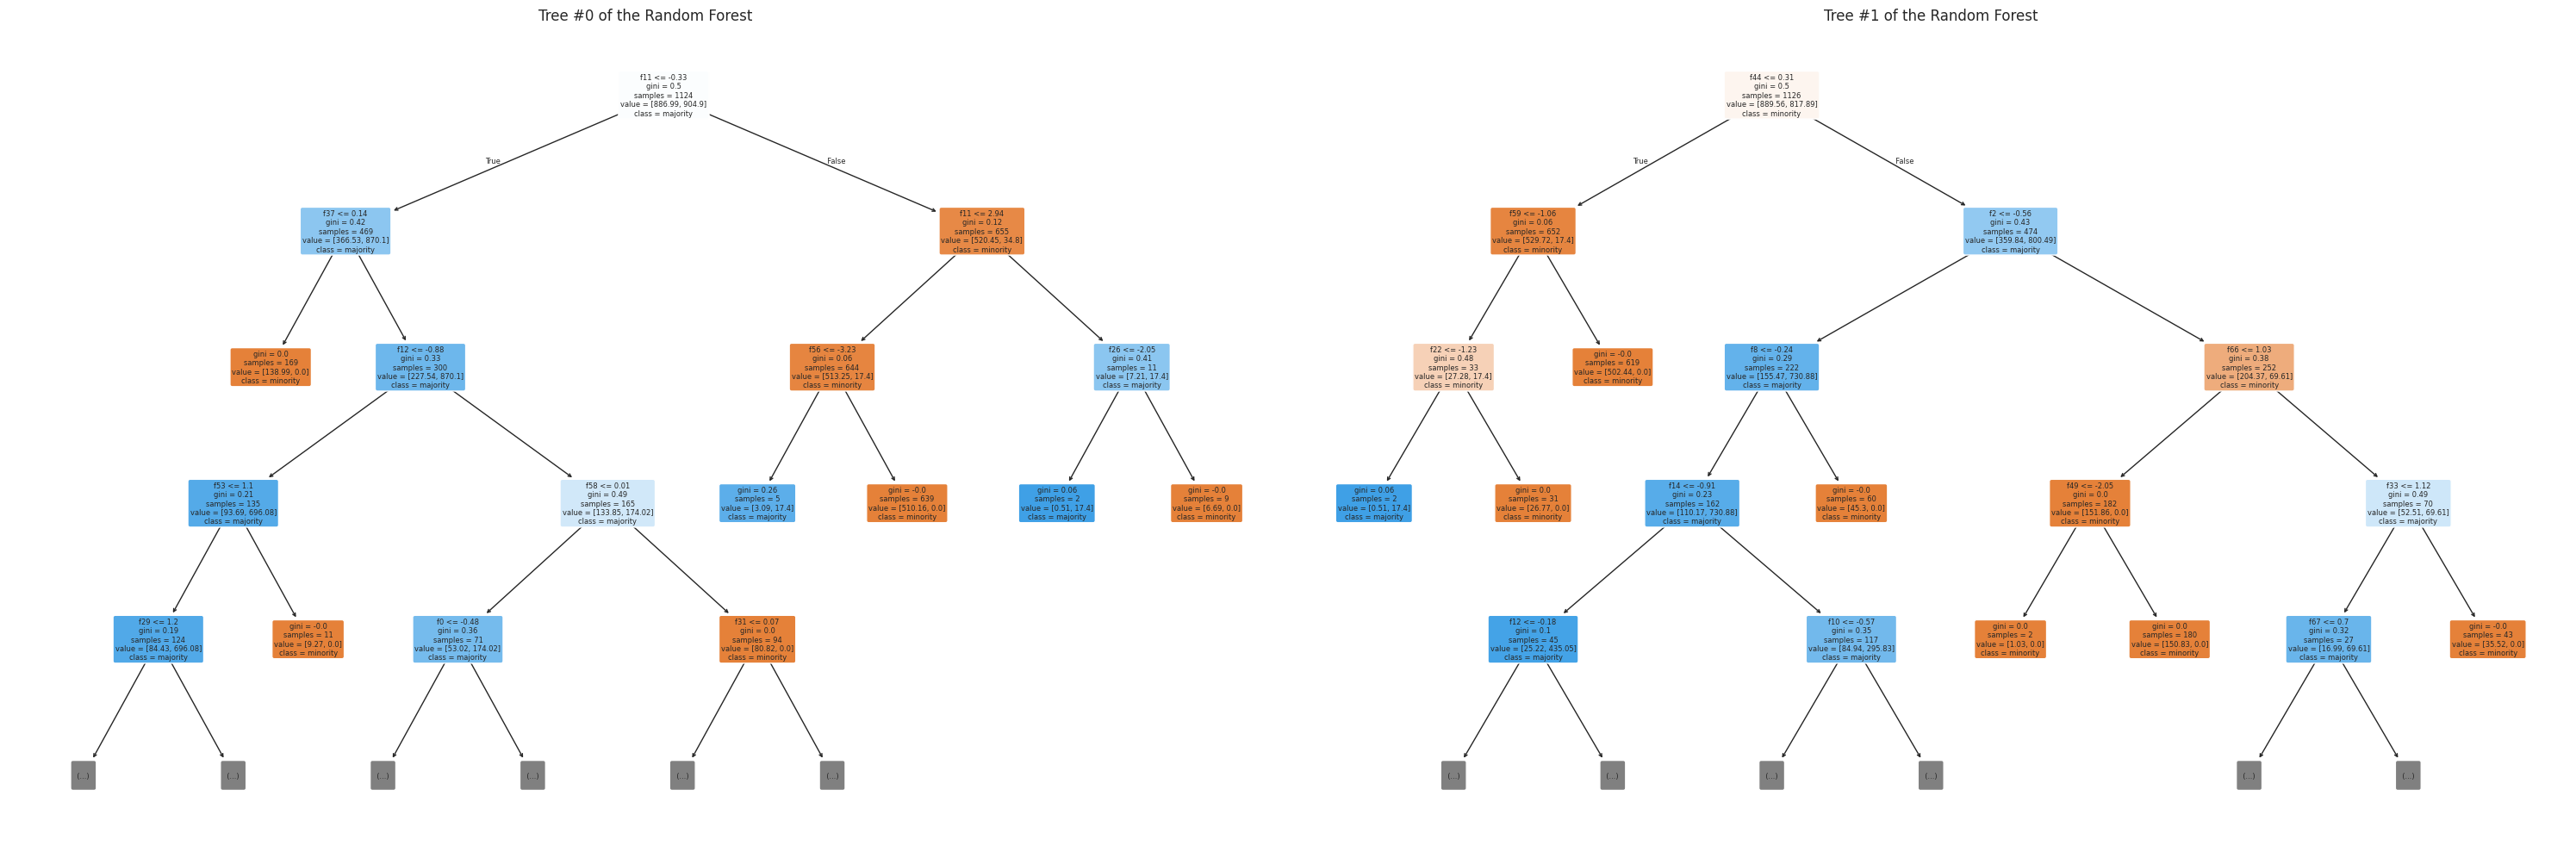


Text representation of Tree #0 (limited depth):
|--- f11 <= -0.33
|   |--- f37 <= 0.14
|   |   |--- class: 0.0
|   |--- f37 >  0.14
|   |   |--- f12 <= -0.88
|   |   |   |--- f53 <= 1.10
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- f53 >  1.10
|   |   |   |   |--- class: 0.0
|   |   |--- f12 >  -0.88
|   |   |   |--- f58 <= 0.01
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- f58 >  0.01
|   |   |   |   |--- truncated branch of depth 2
|--- f11 >  -0.33
|   |--- f11 <= 2.94
|   |   |--- f56 <= -3.23
|   |   |   |--- class: 1.0
|   |   |--- f56 >  -3.23
|   |   |   |--- class: 0.0
|   |--- f11 >  2.94
|   |   |--- f26 <= -2.05
|   |   |   |--- class: 1.0
|   |   |--- f26 >  -2.05
|   |   |   |--- class: 0.0



In [15]:
fig, axes = plt.subplots(1, 2, figsize=(30, 10))

# First two trees of the forest
for i, ax in enumerate(axes):
    tree = best_rf.estimators_[i]
    plot_tree(
        tree,
        feature_names=[f'f{j}' for j in range(X.shape[1])],
        class_names=['minority', 'majority'],
        filled=True, rounded=True, fontsize=6,
        max_depth=4,          # limit displayed depth for readability
        ax=ax,
        impurity=True, precision=2
    )
    ax.set_title(f'Tree #{i} of the Random Forest', fontsize=12)

plt.tight_layout()
plt.savefig('rf_two_trees.png', dpi=150, bbox_inches='tight')
plt.show()

# Textual representation of the first tree
print("\nText representation of Tree #0 (limited depth):")
print(export_text(best_rf.estimators_[0],
                  feature_names=[f'f{j}' for j in range(X.shape[1])],
                  max_depth=3))

### Tree Structure Explanation

In [16]:
tree0 = best_rf.estimators_[0]
print(f"\nTree #0 structure:")
print(f"  Max depth:            {tree0.get_depth()}")
print(f"  Number of leaves:     {tree0.get_n_leaves()}")
print(f"  Number of nodes:      {tree0.tree_.node_count}")
print(f"  Root split feature:   f{tree0.tree_.feature[0]}")
print(f"  Root split threshold: {tree0.tree_.threshold[0]:.4f}")
print(f"  Root impurity:        {tree0.tree_.impurity[0]:.4f}")

print(f"\nTree #1 structure:")
tree1 = best_rf.estimators_[1]
print(f"  Max depth:            {tree1.get_depth()}")
print(f"  Number of leaves:     {tree1.get_n_leaves()}")
print(f"  Number of nodes:      {tree1.tree_.node_count}")
print(f"  Root split feature:   f{tree1.tree_.feature[0]}")
print(f"  Root split threshold: {tree1.tree_.threshold[0]:.4f}")
print(f"  Root impurity:        {tree1.tree_.impurity[0]:.4f}")


Tree #0 structure:
  Max depth:            5
  Number of leaves:     12
  Number of nodes:      23
  Root split feature:   f11
  Root split threshold: -0.3274
  Root impurity:        0.5000

Tree #1 structure:
  Max depth:            5
  Number of leaves:     13
  Number of nodes:      25
  Root split feature:   f44
  Root split threshold: 0.3094
  Root impurity:        0.4991


### Summary Table

In [17]:
summary = pd.DataFrame({
    'Model': ['SVM', 'KNN', 'RF'],
    'Best params': [
        str(svm_grid.best_params_),
        str(knn_grid.best_params_),
        str(rf_grid.best_params_),
    ],
    'CV F1 (minority)': [
        svm_grid.best_score_,
        knn_grid.best_score_,
        rf_grid.best_score_,
    ],
    'Test Accuracy': [
        accuracy_score(y_test, y_test_pred),
        accuracy_score(y_test, y_test_pred_knn),
        accuracy_score(y_test, y_test_pred_rf),
    ],
    'Test Recall (min)': [
        recall_score(y_test, y_test_pred, pos_label=-1),
        recall_score(y_test, y_test_pred_knn, pos_label=-1),
        recall_score(y_test, y_test_pred_rf, pos_label=-1),
    ],
    'Test Precision (min)': [
        precision_score(y_test, y_test_pred, pos_label=-1),
        precision_score(y_test, y_test_pred_knn, pos_label=-1),
        precision_score(y_test, y_test_pred_rf, pos_label=-1),
    ],
    'Test F1 (min)': [
        f1_score(y_test, y_test_pred, pos_label=-1),
        f1_score(y_test, y_test_pred_knn, pos_label=-1),
        f1_score(y_test, y_test_pred_rf, pos_label=-1),
    ],
    'Train time (s)': [svm_time, knn_time, rf_time],
})

print(summary.to_string(index=False))
summary.to_csv('model_comparison.csv', index=False)

Model                                                                                                                            Best params  CV F1 (minority)  Test Accuracy  Test Recall (min)  Test Precision (min)  Test F1 (min)  Train time (s)
  SVM                                                                  {'C': 1, 'coef0': 1, 'degree': 4, 'gamma': 'scale', 'kernel': 'poly'}          0.412403       0.951380           0.975643              0.974324       0.974983        9.484984
  KNN                                                                        {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}          0.314943       0.971091           0.997294              0.973580       0.985294        1.174144
   RF {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}          0.434059       0.939553           0.952639              0.984615       0.968363      162.245707


### Timing Comparison

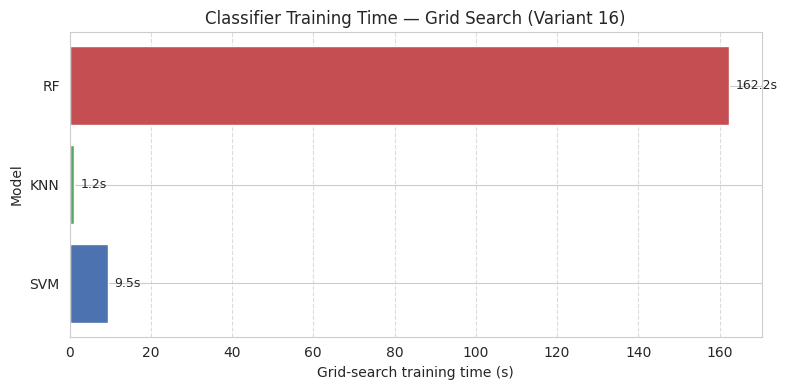

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))

models = summary['Model'].tolist()
times  = summary['Train time (s)'].tolist()
colors = ['#4C72B0', '#55A868', '#C44E52']

bars = ax.barh(models, times, color=colors)
ax.set_xlabel('Grid-search training time (s)')   # TIME ON X-AXIS
ax.set_ylabel('Model')
ax.set_title('Classifier Training Time — Grid Search (Variant 16)')
ax.grid(axis='x', linestyle='--', alpha=0.7)

for bar, t in zip(bars, times):
    ax.text(t + max(times) * 0.01, bar.get_y() + bar.get_height()/2,
            f'{t:.1f}s', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_timing.png', dpi=150)
plt.show()